In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as pltc
from mne.preprocessing import ICA
from scipy.stats import ttest_rel

In [3]:
#load the bdf file
raw = mne.io.read_raw_bdf("P07.bdf", preload=True)

#make mapping of EEG channels depending on size
channel_mappings = {
    'small': {
        'EEG 4': 'P4',
        'EEG 6': 'Fz',
        'EEG 7': 'P3'
    },
    'medium': {
        'EEG 1': 'P3',
        'EEG 2': 'Fz',
        'EEG 3': 'P4'
    },
    'large': {
        'EEG 1': 'P3',
        'EEG 5': 'P4',
        'EEG 8': 'Fz'
    }
}

headset_size = input("Enter size from channel_mappings (small, medium, large): ").strip().lower()

if headset_size not in channel_mappings:
    raise ValueError("Invalid headset size!")

mapping_to_use = channel_mappings[headset_size]

# Rename channels
raw.rename_channels(mapping_to_use)

# Keep only channels you care about
channels_of_interest = ['Fz', 'P3', 'P4']
raw.pick(channels_of_interest)

Extracting BDF parameters from P07.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 118999  =      0.000 ...   475.996 secs...


Enter size from channel_mappings (small, medium, large):  large


<RawBDF | P07.bdf, 3 x 119000 (476.0 s), ~2.7 MiB, data loaded>

In [5]:
b1_start = float(input("Baseline 1 start time (seconds): "))
b1_end = float(input("Baseline 1 end time (seconds): "))

e1_start = float(input("Experimental 1 start time (seconds): "))
e1_end = float(input("Experimental 1 end time (seconds): "))

b2_start = float(input("Baseline 2 start time (seconds): "))
b2_end = float(input("Baseline 2 end time (seconds): "))

e2_start = float(input("Experimental 2 start time (seconds): "))
e2_end = float(input("Experimental 2 end time (seconds): "))

#crop each segment
baseline1 = raw_clean.copy().crop(tmin=b1_start, tmax=b1_end)
experimental1 = raw_clean.copy().crop(tmin=e1_start, tmax=e1_end)
baseline2 = raw_clean.copy().crop(tmin=b2_start, tmax=b2_end)
experimental2 = raw_clean.copy().crop(tmin=e2_start, tmax=e2_end)


Baseline 1 start time (seconds):  158
Baseline 1 end time (seconds):  168
Experimental 1 start time (seconds):  217
Experimental 1 end time (seconds):  293
Baseline 2 start time (seconds):  311
Baseline 2 end time (seconds):  321
Experimental 2 start time (seconds):  341
Experimental 2 end time (seconds):  415


In [7]:
beat_first = input("Which monaural beat did the participant start with? (theta/gamma): ").strip().lower()
if beat_first not in ['theta', 'gamma']:
    raise ValueError("Invalid input! Must be 'theta' or 'gamma'.")

if beat_first == "theta":
    fz_segments = {
        "baseline": baseline1,
        "experimental": experimental1}
    parietal_segments = {
        "baseline": baseline2,
        "experimental": experimental2}
else:  #gamma was first
    parietal_segments = {
        "baseline": baseline1,
        "experimental": experimental1}
    fz_segments = {
        "baseline": baseline2,
        "experimental": experimental2}

#apply theta bandpass filter (4–8 Hz) to Fz for Fz/theta first segments
for name, seg in fz_segments.items():
    seg.filter(
        l_freq=4,
        h_freq=8,
        picks=["Fz"],
        method='iir',
        iir_params={'order': 6, 'ftype': 'butter'},  #Greater order = Harsher cutoff
        phase='zero'
    )

#apply gamma bandpass filter (30–50 Hz) to P3 and P4 for parietal/gamma first segments
for name, seg in parietal_segments.items():
    seg.filter(
        l_freq=30,
        h_freq=50,
        picks=["P3", "P4"],
        method='iir',
        iir_params={'order': 6, 'ftype': 'butter'},
        phase='zero'
    )


Which monaural beat did the participant start with? (theta/gamma):  theta


Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 8 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 4.00, 8.00 Hz: -6.02, -6.02 dB

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 8 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 4.00, 8.00 Hz: -6.02, -6.02 dB

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting 

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 3 channels (please be patient, this may take a while)
Selecting by explained variance: 2 components
Fitting ICA took 0.1s.


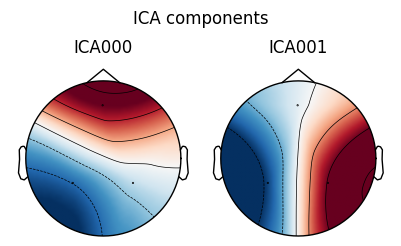

Creating RawArray with float64 data, n_channels=2, n_times=119000
    Range : 0 ... 118999 =      0.000 ...   475.996 secs
Ready.


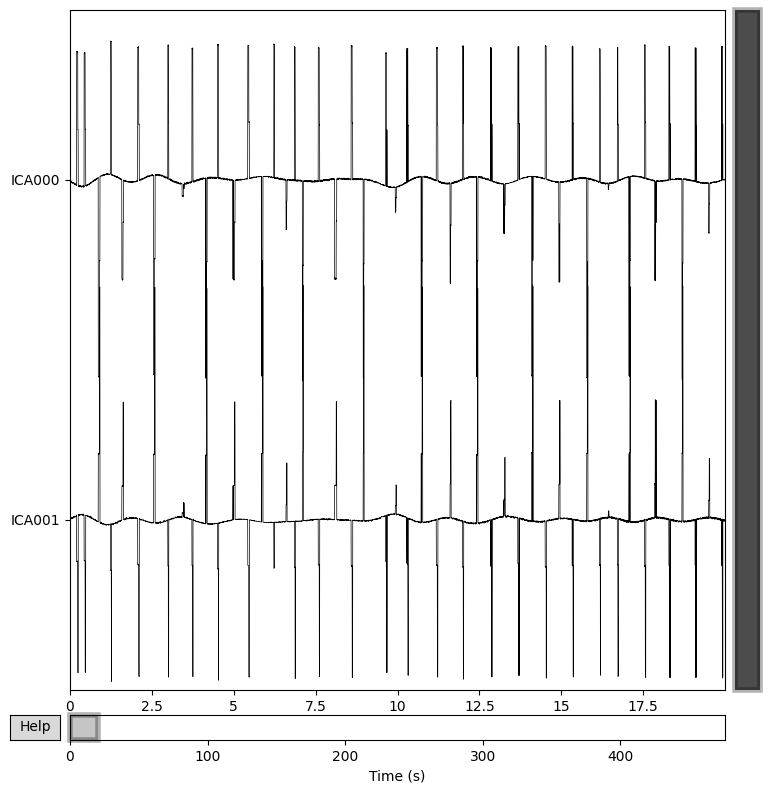

Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 1 ICA component
    Projecting back using 3 PCA components


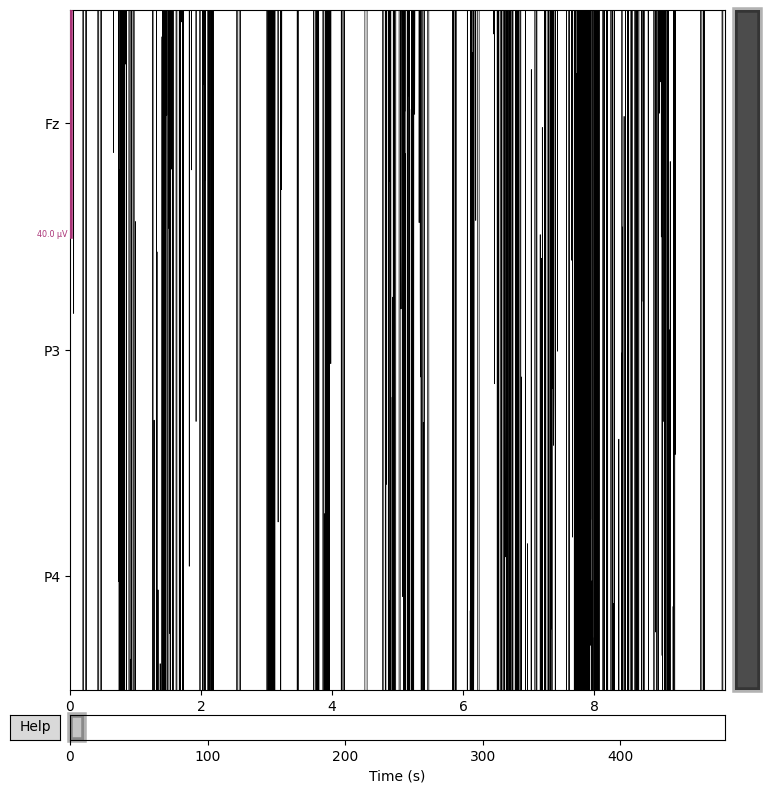

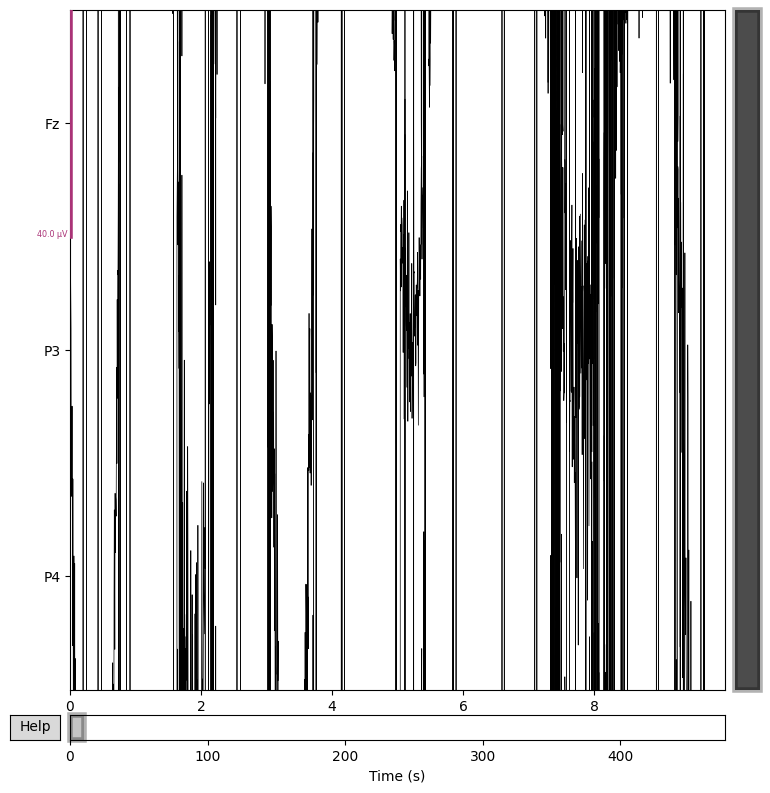

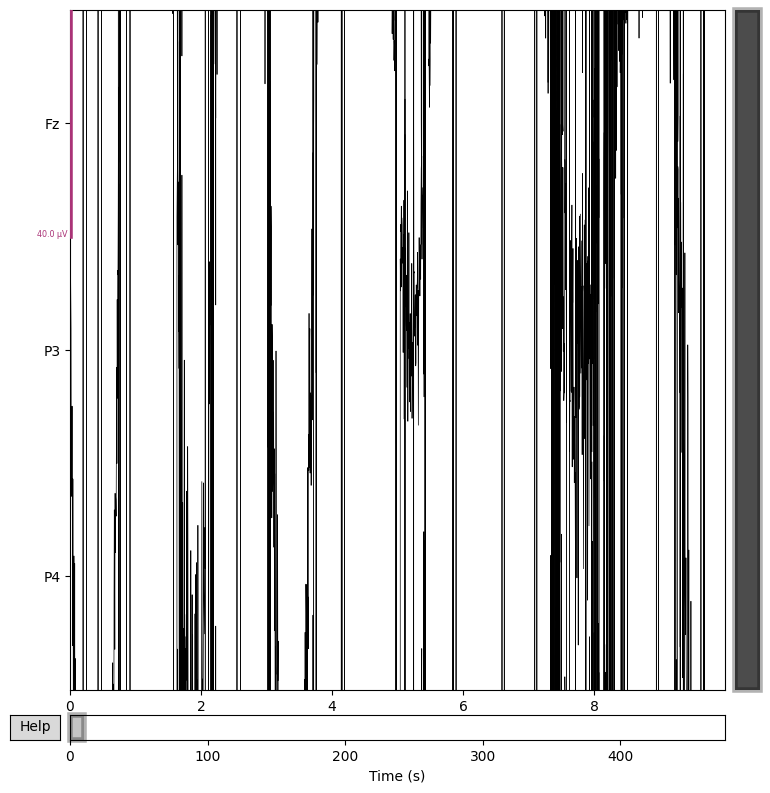

In [8]:
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

raw.set_eeg_reference("average", projection=False)

raw.filter(l_freq=1.0, h_freq=None)

ica = ICA(
    n_components=0.95, #95
    method="fastica",
    random_state=97,
    max_iter="auto"
)

ica.fit(raw)

ica.plot_components()
ica.plot_sources(raw)

ica.exclude = [0, 2]

raw_clean = ica.apply(raw.copy())

raw.plot(title="Before ICA")
raw_clean.plot(title="After ICA")

In [9]:
#calculate Fz theta-band mean
fz_means = {} #[baseline, expeirmental]
for name, seg in fz_segments.items():
    data = seg.copy().pick(['Fz']).get_data()
    fz_means[name] = np.mean(data)

#calculate P3 and P4 gamma-band mean
parietal_means = {} #pooled p3+p4 means [baseline, experimental]
for name, seg in parietal_segments.items():
    data = seg.copy().pick(['P3','P4']).get_data()
    parietal_means[name] = np.mean(data, axis=(0,1))

#compute percent means
fz_percent_change = ((fz_means['experimental'] - fz_means['baseline']) / abs(fz_means['baseline'])) * 100

parietal_percent_change = ((parietal_means['experimental'] - parietal_means['baseline']) / abs(parietal_means['baseline'])) * 100

#check if working
print("Fz theta percent change from baseline:", fz_percent_change)
print("P3+P4 gamma percent change from baseline:", parietal_percent_change)

Fz theta percent change from baseline: 99.2390251695461
P3+P4 gamma percent change from baseline: -42.943476675198404
